In [3]:
import kagglehub
data_path = kagglehub.dataset_download('rahimanshu/cardiomegaly-disease-prediction-using-cnn')

print('Data source import complete.')

100%|██████████| 61.7M/61.7M [00:00<00:00, 211MB/s]

Extracting files...


Data source import complete.


In [4]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam , Adamax
from tensorflow.keras.regularizers import L2, L1
from tensorflow.keras.applications import DenseNet121

import plotly.graph_objects as go
from plotly.subplots import make_subplots

import warnings
warnings.filterwarnings('ignore')

In [5]:
true_train_path = data_path + '/train/train/true/'
false_train_path = data_path +'/train/train/false/'

true_train_imgs = len(os.listdir(true_train_path))
false_train_imgs = len(os.listdir(false_train_path))
all_train_imgs = false_train_imgs + false_train_imgs

print(f"All Training Images : {all_train_imgs} images")
print(f"True Training Images : {true_train_imgs} images")
print(f"False Training Images : {false_train_imgs} images")

All Training Images : 4438 images
True Training Images : 2219 images
False Training Images : 2219 images


In [6]:
true_test_path = data_path + '/test/test/true/'
false_test_path = data_path + '/test/test/false/'

true_test_imgs = len(os.listdir(true_test_path))
false_test_imgs = len(os.listdir(false_test_path))
all_test_imgs = false_test_imgs + false_test_imgs

print(f"All Testing Images : {all_test_imgs} images")
print(f"True Testing Images : {true_test_imgs} images")
print(f"False Testing Images : {false_test_imgs} images")

All Testing Images : 1114 images
True Testing Images : 557 images
False Testing Images : 557 images


In [7]:
df_true_train = pd.DataFrame({'Images': os.listdir(true_train_path)})
df_true_train['Images'] = true_train_path + df_true_train['Images']
df_true_train['Target'] = 'true'

df_false_train = pd.DataFrame({'Images': os.listdir(false_train_path)})
df_false_train['Images'] = false_train_path + df_false_train['Images']
df_false_train['Target'] = 'false'

df_train = pd.concat([df_true_train, df_false_train])
df_train= df_train.sample(frac=1, random_state=42).reset_index(drop=True)
df_train

,Images,Target
0,/root/.cache/kagglehub/datasets/rahimanshu/car...,false
1,/root/.cache/kagglehub/datasets/rahimanshu/car...,false
2,/root/.cache/kagglehub/datasets/rahimanshu/car...,false
3,/root/.cache/kagglehub/datasets/rahimanshu/car...,true
4,/root/.cache/kagglehub/datasets/rahimanshu/car...,true
...,...,...
4433,/root/.cache/kagglehub/datasets/rahimanshu/car...,false
4434,/root/.cache/kagglehub/datasets/rahimanshu/car...,true
4435,/root/.cache/kagglehub/datasets/rahimanshu/car...,false
4436,/root/.cache/kagglehub/datasets/rahimanshu/car...,false


In [8]:
df_train['Target'].value_counts()

,count
Target,
false,2219
true,2219


In [9]:
df_true_test = pd.DataFrame({'Images': os.listdir(true_test_path)})
df_true_test['Images'] = true_test_path + df_true_test['Images']
df_true_test['Target'] = 'true'

df_false_test = pd.DataFrame({'Images': os.listdir(false_test_path)})
df_false_test['Images'] = false_test_path + df_false_test['Images']
df_false_test['Target'] = 'false'

df_test = pd.concat([df_true_test, df_false_test])
df_test  = df_test.sample(frac=1, random_state=42).reset_index(drop=True)
df_test

,Images,Target
0,/root/.cache/kagglehub/datasets/rahimanshu/car...,false
1,/root/.cache/kagglehub/datasets/rahimanshu/car...,true
2,/root/.cache/kagglehub/datasets/rahimanshu/car...,false
3,/root/.cache/kagglehub/datasets/rahimanshu/car...,false
4,/root/.cache/kagglehub/datasets/rahimanshu/car...,true
...,...,...
1109,/root/.cache/kagglehub/datasets/rahimanshu/car...,true
1110,/root/.cache/kagglehub/datasets/rahimanshu/car...,true
1111,/root/.cache/kagglehub/datasets/rahimanshu/car...,false
1112,/root/.cache/kagglehub/datasets/rahimanshu/car...,false


In [10]:
df_valid, df_test = train_test_split(df_test, test_size=0.5, random_state=101, shuffle = True,  stratify =df_test['Target'])

In [11]:
df_test['Target'].value_counts()

,count
Target,
true,279
false,278


In [12]:
df_valid['Target'].value_counts()

,count
Target,
false,279
true,278


In [13]:
img_size = (224,224)
batch_size = 32


train_data_gen  = ImageDataGenerator(
                                    rescale=1./255,
                                    rotation_range=10,            # small, realistic rotations
                                    width_shift_range=0.05,       # mild shifts
                                    height_shift_range=0.05,
                                    zoom_range=0.1,               # zoom in/out a little
                                    brightness_range=[0.8, 1.2],  # simulate different exposure levels
                                    fill_mode='nearest'          # fill in missing pixels after transformation
                                )

valid_data_gen  = ImageDataGenerator(rescale=1./255)
test_data_gen = ImageDataGenerator(rescale=1./255)

train_gen = train_data_gen.flow_from_dataframe(df_train , x_col = 'Images' , y_col = 'Target' , target_size = img_size ,
                                      class_mode = 'binary' , batch_size =batch_size)

valid_gen = valid_data_gen.flow_from_dataframe(df_valid , x_col = 'Images' , y_col = 'Target' , target_size = img_size ,
                                       class_mode = 'binary', batch_size = batch_size, shuffle=False)

test_gen = test_data_gen.flow_from_dataframe(df_test , x_col= 'Images' , y_col = 'Target' , target_size = img_size ,
                                      class_mode = 'binary', batch_size = batch_size, shuffle=False)

Found 4438 validated image filenames belonging to 2 classes.
Found 557 validated image filenames belonging to 2 classes.
Found 557 validated image filenames belonging to 2 classes.


In [14]:
print(train_gen.class_indices)

{'false': 0, 'true': 1}


In [15]:
def plot_history(history):
    # Extract training history data
    train_loss = history.history['loss']
    val_loss = history.history['val_loss']
    train_accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']

    # Create subplots: 1 row, 2 columns
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=('Training and Validation Loss', 'Training and Validation Accuracy'),
    )

    # Add trace for loss
    fig.add_trace(
        go.Scatter(x=list(range(1, len(train_loss) + 1)), y=train_loss, mode='lines', name='Train Loss', line=dict(color='blue')),
        row=1, col=1
    )
    fig.add_trace(
        go.Scatter(x=list(range(1, len(val_loss) + 1)), y=val_loss, mode='lines', name='Validation Loss', line=dict(color='red')),
        row=1, col=1
    )

    # Add trace for accuracy
    fig.add_trace(
        go.Scatter(x=list(range(1, len(train_accuracy) + 1)), y=train_accuracy, mode='lines', name='Train Accuracy', line=dict(color='green')),
        row=1, col=2
    )
    fig.add_trace(
        go.Scatter(x=list(range(1, len(val_accuracy) + 1)), y=val_accuracy, mode='lines', name='Validation Accuracy', line=dict(color='black')),
        row=1, col=2
    )

    # Update layout
    fig.update_layout(
        template="presentation",
        title="Model Performance: Loss and Accuracy",
        xaxis_title="Epochs",
        yaxis_title="Loss",
        xaxis2_title="Epochs",
        yaxis2_title="Accuracy",
        height=500,
        showlegend=True
    )

    # Show plot
    fig.show()

In [16]:
# Load DenseNet121 base model
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.3)(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

dense_model = Model(inputs=base_model.input, outputs=output)


dense_model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# dense_model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [17]:
my_callbacks3 = [ EarlyStopping(monitor='val_loss', patience=5, min_delta=0.001, restore_best_weights=True),
                 ModelCheckpoint('weights3.keras', monitor='val_loss', save_best_only=True, verbose=1),
                 ReduceLROnPlateau(patience=3, factor=0.2, verbose=1)]

In [18]:
history3 = dense_model.fit(train_gen, validation_data=valid_gen, epochs=50, verbose=1, callbacks= my_callbacks3)

Epoch 1/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 536ms/step - accuracy: 0.5950 - loss: 0.7787
Epoch 1: val_loss improved from inf to 0.62945, saving model to weights3.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 131s 729ms/step - accuracy: 0.5951 - loss: 0.7786 - val_accuracy: 0.6517 - val_loss: 0.6295 - learning_rate: 0.0010
Epoch 2/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.6441 - loss: 0.6750
Epoch 2: val_loss improved from 0.62945 to 0.60355, saving model to weights3.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 59s 427ms/step - accuracy: 0.6441 - loss: 0.6749 - val_accuracy: 0.6715 - val_loss: 0.6036 - learning_rate: 0.0010
Epoch 3/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.6805 - loss: 0.6171
Epoch 3: val_loss improved from 0.60355 to 0.59339, saving model to weights3.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 60s 428ms/step - accuracy: 0.6805 - loss: 0.6171 - val_accuracy: 0.6822 - val_loss: 0.5934 - learning_rate: 0.0010
Epoch 4/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - ac

In [19]:
plot_history(history3)

18/18 ━━━━━━━━━━━━━━━━━━━━ 24s 759ms/step


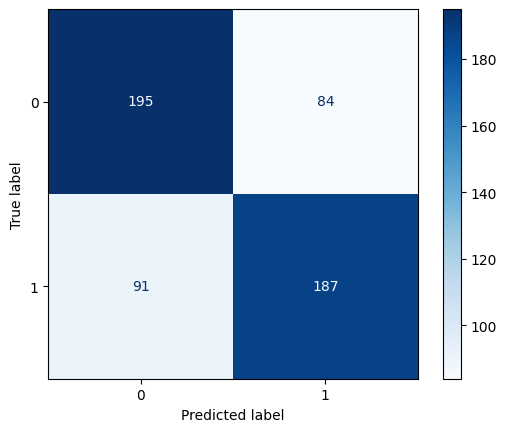

              precision    recall  f1-score   support

           0       0.68      0.70      0.69       279
           1       0.69      0.67      0.68       278

    accuracy                           0.69       557
   macro avg       0.69      0.69      0.69       557
weighted avg       0.69      0.69      0.69       557



In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

y_valid = df_valid['Target'].map({'true':1,'false':0})

# Predictions on the validation set
y_prob = dense_model.predict(valid_gen)
y_pred = (y_prob >=0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_valid, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.show()

# Classification report
print(classification_report(y_valid,y_pred))


In [21]:
# 1. Unfreeze the base model
base_model.trainable = True

# 2. Freeze all layers except the last 20 (for example)
for layer in base_model.layers[:-20]:
    layer.trainable = False

# 3. Re-compile with a very low learning rate
dense_model.compile(optimizer=Adam(learning_rate=1e-5), # سرعة تعلم بطيئة جداً
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 4. Train again for a few epochs
history_fine = dense_model.fit(train_gen, validation_data=valid_gen, epochs=10, callbacks=my_callbacks3)

Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step - accuracy: 0.7063 - loss: 0.5655
Epoch 1: val_loss did not improve from 0.57759
139/139 ━━━━━━━━━━━━━━━━━━━━ 124s 672ms/step - accuracy: 0.7064 - loss: 0.5654 - val_accuracy: 0.6840 - val_loss: 0.5879 - learning_rate: 1.0000e-05
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.7051 - loss: 0.5631
Epoch 2: val_loss did not improve from 0.57759
139/139 ━━━━━━━━━━━━━━━━━━━━ 58s 420ms/step - accuracy: 0.7052 - loss: 0.5630 - val_accuracy: 0.7002 - val_loss: 0.5830 - learning_rate: 1.0000e-05
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.7365 - loss: 0.5247
Epoch 3: val_loss did not improve from 0.57759
139/139 ━━━━━━━━━━━━━━━━━━━━ 57s 413ms/step - accuracy: 0.7364 - loss: 0.5248 - val_accuracy: 0.7038 - val_loss: 0.5835 - learning_rate: 1.0000e-05
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.7162 - loss: 0.5366
Epoch 4: val_loss did not improve from 0.57759
139/139 ━━━━━━━

18/18 ━━━━━━━━━━━━━━━━━━━━ 25s 753ms/step


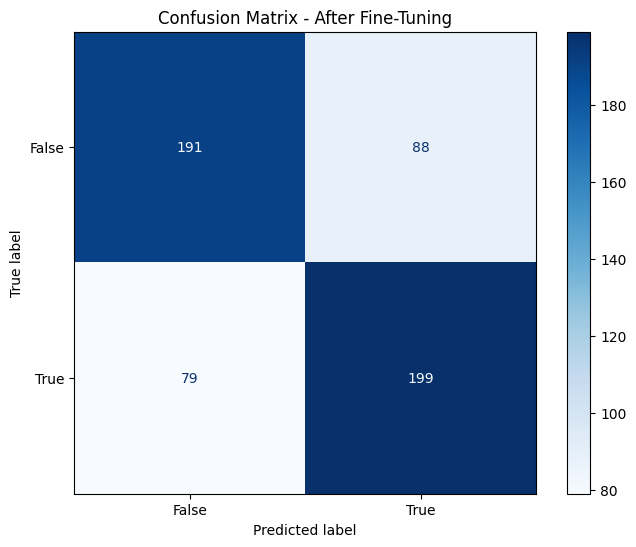

              precision    recall  f1-score   support

       False       0.71      0.68      0.70       279
        True       0.69      0.72      0.70       278

    accuracy                           0.70       557
   macro avg       0.70      0.70      0.70       557
weighted avg       0.70      0.70      0.70       557



In [22]:
valid_gen.reset()

y_prob = dense_model.predict(valid_gen)
y_pred = (y_prob >= 0.5).astype(int).flatten()
y_true = valid_gen.classes

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['False', 'True'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix - After Fine-Tuning')
plt.show()

print(classification_report(y_true, y_pred, target_names=['False', 'True']))